# 12 — Production Monitoring, Drift, Retraining, and Business Decisioning (Manual NumPy)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Deployment is the start of another feedback loop. A production ANN needs monitoring for input quality, data drift, prediction distribution, confidence, latency, system failures and—when labels arrive—real performance. Drift is not automatically failure, but it is evidence that the training assumptions may no longer match reality.

### Monitoring layers
1. **Data:** schema, range, missingness, brightness/pixel statistics, class proxies.
2. **Model output:** class mix, confidence, entropy, abstention rate.
3. **Performance:** delayed accuracy/F1/calibration when labels arrive.
4. **System:** latency, throughput, error rate, CPU/GPU/memory.
5. **Business:** automation rate, review workload, downstream loss/value.


## Code walkthrough — simulate a production covariate shift
We darken test images to emulate a sensor/ingestion shift. The labels are unchanged, but the input distribution moves. We compare mean intensity and a simple distribution distance. In real systems this might be a population shift, new retailer, new document template or changed transaction behavior.


baseline mean/std 0.13208503 0.3099568
drifted  mean/std 0.072646774 0.17047621
illustrative pixel-distribution PSI 37.366343706492316


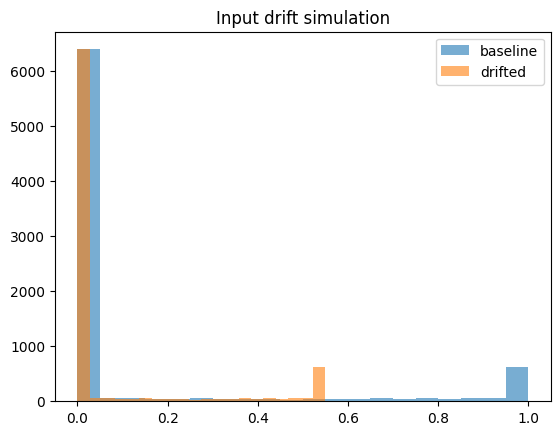

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
X_drift = np.clip(X_test * 0.55, 0, 1)
print("baseline mean/std", X_test.mean(), X_test.std())
print("drifted  mean/std", X_drift.mean(), X_drift.std())
base_hist, _ = np.histogram(X_test, bins=20, range=(0, 1), density=True)
drift_hist, _ = np.histogram(X_drift, bins=20, range=(0, 1), density=True)
psi = np.sum(
    (drift_hist + 1e-06 - base_hist - 1e-06)
    * np.log((drift_hist + 1e-06) / (base_hist + 1e-06))
)
print("illustrative pixel-distribution PSI", psi)
plt.hist(X_test.ravel()[::100], bins=20, alpha=0.6, label="baseline")
plt.hist(X_drift.ravel()[::100], bins=20, alpha=0.6, label="drifted")
plt.legend()
plt.title("Input drift simulation")
plt.show()

## Code walkthrough — connect input drift to actual model behavior
Input drift matters because it can change predictions, confidence and real accuracy. We reload the exact artifact from the training notebook, score both baseline and darkened images, and compare accuracy, average confidence and predicted-class mix. This is the minimum bridge from statistical drift to operational impact.


baseline accuracy/confidence 0.877 0.8095
drifted  accuracy/confidence 0.878 0.6309
baseline predicted mix [103 104 104  89 105  86 104  82  82 141]
drifted  predicted mix [102 106 100  87 107  90 107  85  79 137]


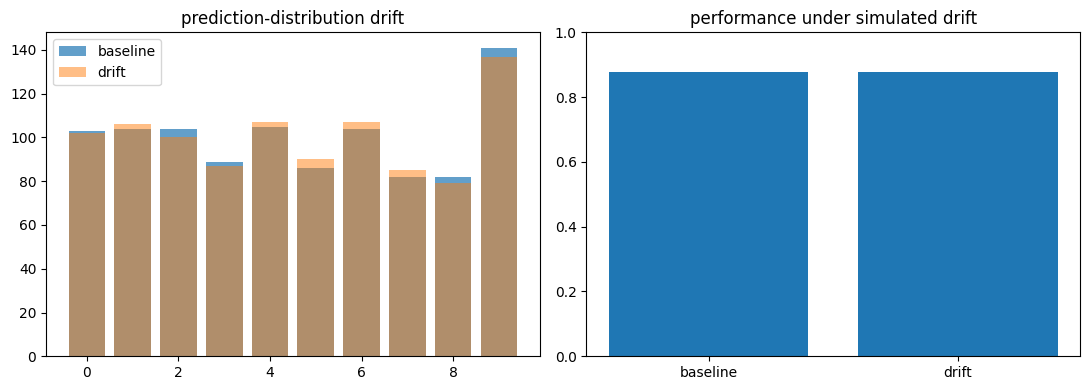

In [2]:
a = np.load(ARTIFACT_DIR / "mnist_manual_mlp.npz")
W1, b1, W2, b2 = [a[k] for k in ["W1", "b1", "W2", "b2"]]


def predict_probs(X):
    h = np.maximum(X @ W1 + b1, 0)
    z = h @ W2 + b2
    e = np.exp(z - z.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)


base_probs = predict_probs(X_test)
drift_probs = predict_probs(X_drift)
base_pred = base_probs.argmax(1)
drift_pred = drift_probs.argmax(1)
base_acc = (base_pred == y_test).mean()
drift_acc = (drift_pred == y_test).mean()
print(
    "baseline accuracy/confidence",
    round(float(base_acc), 4),
    round(float(base_probs.max(1).mean()), 4),
)
print(
    "drifted  accuracy/confidence",
    round(float(drift_acc), 4),
    round(float(drift_probs.max(1).mean()), 4),
)
print("baseline predicted mix", np.bincount(base_pred, minlength=10))
print("drifted  predicted mix", np.bincount(drift_pred, minlength=10))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    range(10), np.bincount(base_pred, minlength=10), alpha=0.7, label="baseline"
)
axes[0].bar(range(10), np.bincount(drift_pred, minlength=10), alpha=0.5, label="drift")
axes[0].legend()
axes[0].set_title("prediction-distribution drift")
axes[1].bar(["baseline", "drift"], [base_acc, drift_acc])
axes[1].set_ylim(0, 1)
axes[1].set_title("performance under simulated drift")
plt.tight_layout()
plt.show()

## Retraining decision contract
A retraining trigger should be governed, not automatic panic. Example: investigate when data-quality checks fail or drift exceeds a threshold; collect fresh labels; compare champion vs candidate on a new validation set; run the untouched regression/test suite; check fairness/safety/business constraints; then promote through deployment controls. Preserve rollback capability.


## Business mapping beyond MNIST
| MNIST concept | Enterprise analogue |
|---|---|
| pixel vector | transaction/document/product/customer features |
| digit class | fraud type, intent, defect, product category, risk band |
| hidden representation | learned customer/document/product embedding |
| misclassification | costly business decision |
| confidence | decision risk / escalation signal |
| drift | changing market, sensor, customer or data-pipeline behavior |
| retraining | governed model lifecycle |

A production model is successful only when technical metrics, operational constraints and business outcomes remain aligned.


## Final mastery checklist
You should now be able to explain the entire system: provenance → split → preprocessing → batching → architecture → initialization → forward → logits → loss → backprop → optimizer → training → validation → final test → error/calibration → artifact → inference → latency → monitoring → drift → retraining → business action. If any link is unclear, return to the corresponding notebook before adding more architecture complexity.


### Interactive Plotly lab — clone + run locally

## Interactive production drift simulator

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

The slider progressively darkens the notebook's real normalized MNIST test pixels. Labels do not change, but the input distribution does, making covariate shift tangible before connecting it to monitoring, delayed-label performance and retraining governance.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [3]:
import os
import numpy as np
import plotly.graph_objects as go

base_pixels = np.asarray(X_test[:300]).reshape(-1); severities = [0.0, 0.15, 0.30, 0.45, 0.60]; samples = [np.clip(base_pixels * (1 - s), 0, 1) for s in severities]
fig = go.Figure(data=[go.Histogram(x=samples[0], nbinsx=40, histnorm="probability", hovertemplate="pixel≈%{x:.3f}<br>probability=%{y:.4f}<extra></extra>")], frames=[go.Frame(name=str(i), data=[go.Histogram(x=arr, nbinsx=40, histnorm="probability")]) for i, arr in enumerate(samples)])
fig.update_layout(title="Interactive covariate-drift simulator: progressive image darkening", xaxis=dict(title="normalized pixel intensity", range=[0, 1]), yaxis_title="probability", sliders=[dict(currentvalue=dict(prefix="darkening severity = "), steps=[dict(label=f"{s:.2f}", method="animate", args=[[str(i)], dict(mode="immediate", frame=dict(duration=0), transition=dict(duration=0))]) for i, s in enumerate(severities)])])
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive drift simulator built. Run locally to move severity and inspect distribution shift.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive drift simulator built. Run locally to move severity and inspect distribution shift.
